d:\


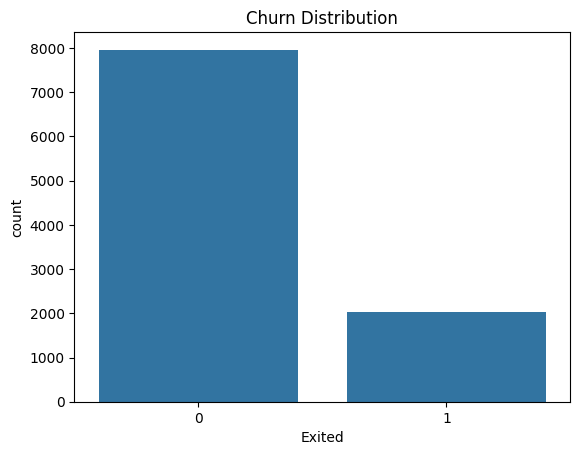


Logistic Regression
F1 Score: 0.275049115913556
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1607
           1       0.60      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.72      0.57      0.58      2000
weighted avg       0.78      0.82      0.77      2000


Decision Tree
F1 Score: 0.5051903114186851
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1607
           1       0.79      0.37      0.51       393

    accuracy                           0.86      2000
   macro avg       0.83      0.67      0.71      2000
weighted avg       0.85      0.86      0.84      2000


Random Forest
F1 Score: 0.524701873935264
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1607
           1       0.79      0.39      0.52       393

    accuracy                           0.86   

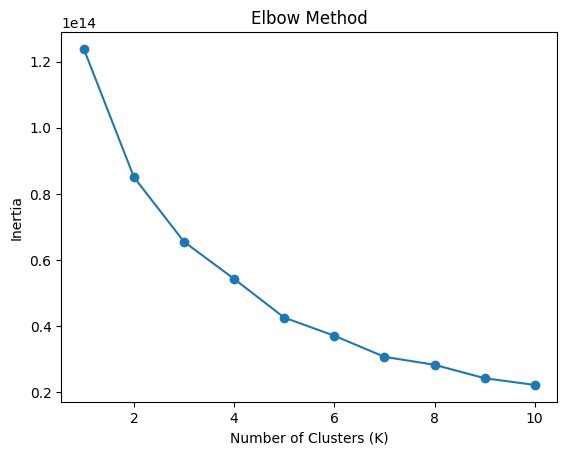

,Model,F1 Score
3,Gradient Boosting,0.561622
2,Random Forest,0.524702
1,Decision Tree,0.505190
0,Logistic Regression,0.275049


In [16]:
import os
os.chdir("..")
print(os.getcwd())

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv(r"D:\PythonAssigment\bank_customer_churn.csv")
sns.countplot(x='Exited', data=data)
plt.title("Churn Distribution")
plt.show()

data.drop_duplicates(inplace=True)
for col in data.select_dtypes(include=['int64', 'float64']).columns:
    data[col].fillna(data[col].median(), inplace=True)
for col in data.select_dtypes(include=['object']).columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

X = data.drop('Exited', axis=1)
y = data['Exited']

for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

params = {
    "Logistic Regression": {'C': [0.01,0.1,1,10], 'penalty': ['l2']},
    "Decision Tree": {"max_depth":[5,10], "min_samples_split":[2,5], "criterion":["gini","entropy"]},
    "Random Forest": {'n_estimators':[100,200], 'max_depth':[5,10], 'min_samples_split':[2,5], 'criterion':['gini','entropy']},
    "Gradient Boosting": {'n_estimators':[100,200], 'learning_rate':[0.05,0.1], 'max_depth':[3,5]}
}

best_models = {}
for name in models:
    grid = GridSearchCV(models[name], params[name], cv=3, scoring='f1')
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    y_pred = best_models[name].predict(X_test)
    print(f"\n{name}")
    print("F1 Score:", f1_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

X_kmeans = X.copy()
kmeans = KMeans(n_clusters=5, random_state=42)
X_kmeans['cluster'] = kmeans.fit_predict(X_kmeans)

inertia = [KMeans(n_clusters=k, random_state=42).fit(X_kmeans).inertia_ for k in range(1,11)]
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

results_df = pd.DataFrame([{"Model": name, "F1 Score": f1_score(y_test, best_models[name].predict(X_test))} for name in best_models])
results_df.sort_values(by="F1 Score", ascending=False, inplace=True)
results_df
